In [1]:
# compute the decision time and model mutual information, transfer entropy, etc from different realizations of the rnn

import numpy as np
from behavior_models import models
from one.api import ONE
from brainbox.io.one import SessionLoader
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
import pickle as pkl

from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI
from idtxl.bivariate_mi import BivariateMI
from idtxl.bivariate_te import BivariateTE
from prior_localization.functions.behavior_targets import optimal_Bayesian
from tqdm import tqdm
import itertools
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import seaborn as sns
from glob import glob
from scipy.special import kl_div
from scipy.stats import gaussian_kde
import re

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/one/alf/files.py:10: FutureWarning: `one.alf.files` will be removed in version 3.0. Use `one.alf.path` instead.
  warnings.warn(
2025-01-16 14:58:23.731 | INFO     | ibl_info.config:<module>:8 - PROJ_ROOT path is: /Users/dkundu/Documents/phd/ibl-partial-info-decomp


In [2]:
# import pyinform
# pyinform doesn't work on my computer, so I'm using the idtxl package instead
from idtxl.data import Data



<b>TODO</b>
>
    1. MI between each hidden neuron and the stimulus, choice, and block side
    2. TE between neurons
    3. Find neurons that have maxmimum MI with block, then compute their TE with the choice neurons
    4. Identify epochs
    5. Load different training stages.
    6. Plot the inputs that the rnns receive, vs the decision times

In [ ]:
# location info : /Users/dkundu/Documents/phd/ann-rnn-modified/data

### Show stimulus parameters


In [3]:
def difference(dist1, dist2):
    kde1 = gaussian_kde(dist1, bw_method="silverman")
    kde2 = gaussian_kde(dist2, bw_method="silverman")

    # Create a range of values to evaluate the PDFs
    x_values = np.linspace(-10, 10, 1000)

    # Compute the PDFs
    pdf1 = kde1(x_values)
    pdf2 = kde2(x_values)

    # Normalize the PDFs (in case they are not normalized)
    pdf1 /= np.sum(pdf1)
    pdf2 /= np.sum(pdf2)

    # Compute KL Divergence (P || Q)
    kl_divergence = np.sum(kl_div(pdf1, pdf2))

    # Estimate the mean and std of the KDEs
    mean1 = np.sum(x_values * pdf1)
    std1 = np.sqrt(np.sum((x_values - mean1) ** 2 * pdf1))

    mean2 = np.sum(x_values * pdf2)
    std2 = np.sqrt(np.sum((x_values - mean2) ** 2 * pdf2))

    # Compute d-prime
    d_prime = (mean1 - mean2) / np.sqrt((std1**2 + std2**2) / 2)
    return kl_divergence, d_prime


def plot_distribtion_separated(stimulus_data, left_trials, right_trials, trial_strengths):

    indices_dict_left = {}
    indices_dict_right = {}

    # Loop over each value and find its indices
    for value in np.unique(trial_strengths[left_trials, 0]):
        indices_dict_left[value] = np.where(trial_strengths[left_trials, 0] == value)[0]

    for value in np.unique(trial_strengths[right_trials, 0]):
        indices_dict_right[value] = np.where(trial_strengths[right_trials, 0] == value)[0]

    fig, ax = plt.subplots(
        figsize=(24, 6), ncols=len(indices_dict_left), nrows=2, sharex=True, sharey=True
    )

    # top row for left trials, bottom row for right trials, similar otherwise
    # when indexing, remeber to use the correct subset

    for idx in range(2):
        for idy in range(len(indices_dict_left.keys())):

            if idx == 0:
                k = list(indices_dict_left.keys())[idy]
                ax[idx][idy].set_title(f"L-stim-strength:{k}")
                data_l = stimulus_data[left_trials, :, 0][indices_dict_left[k]].reshape(
                    -1,
                )
                data_r = stimulus_data[left_trials, :, 1][indices_dict_left[k]].reshape(
                    -1,
                )
            else:
                k = list(indices_dict_right.keys())[idy]
                ax[idx][idy].set_title(f"Ri-stim-strength:{k}")
                data_l = stimulus_data[right_trials, :, 0][indices_dict_right[k]].reshape(
                    -1,
                )
                data_r = stimulus_data[right_trials, :, 1][indices_dict_right[k]].reshape(
                    -1,
                )

            # now just plot them
            sns.kdeplot(data_l, color="red", label="left", ax=ax[idx][idy])
            sns.kdeplot(data_r, color="blue", label="right", ax=ax[idx][idy])

            # add text for KL divergence and estimated dprime
            kldivergence, dprime = difference(data_l, data_r)
            _, ymax = ax[idx, idy].get_ylim()
            xmin, _ = ax[idx, idy].get_xlim()
            ax[idx, idy].text(
                xmin + 0.1,
                ymax - 0.1,
                f"KL-div:{kldivergence:0.2f}, dprime:{np.abs(dprime):0.2f}",
            )

    plt.legend()


def stimulus_generator(
    possible_trial_strengths=None,
    possible_trial_probabilities=None,
    num_trials=1000,
    block_side_bias_probabilities=[0.5, 0.5],
    max_rnn_steps_per_trial=12,
    noise_scale=1.0,
    signal_scale=1.0,
):

    if possible_trial_strengths is None:
        possible_trial_strengths = tuple(np.linspace(0, 2.5, 6))
    if possible_trial_probabilities is None:
        possible_trial_probabilities = tuple(np.ones(6) / 6)

    trial_strengths = np.random.choice(
        possible_trial_strengths, p=possible_trial_probabilities, size=(num_trials, 1)
    )

    # hold trial strength constant for duration of trial
    trial_strengths = np.repeat(a=trial_strengths, repeats=max_rnn_steps_per_trial, axis=1)
    signal_sides_indices = np.random.choice(
        [0, 1], p=block_side_bias_probabilities, size=(num_trials, 1)
    )
    signal_sides_indices = np.repeat(
        signal_sides_indices, axis=-1, repeats=max_rnn_steps_per_trial
    )

    trial_sides = 2 * signal_sides_indices - 1

    left_trials = np.argwhere(signal_sides_indices[:, 0] == 0).reshape(
        -1,
    )
    right_trials = np.argwhere(signal_sides_indices[:, 0] == 1).reshape(
        -1,
    )

    signal = np.random.normal(
        loc=trial_strengths, scale=np.ones_like(trial_strengths) * signal_scale
    )
    # now generate noise
    sampled_stimuli = np.random.normal(
        loc=0.0, scale=noise_scale, size=(num_trials, max_rnn_steps_per_trial, 2)
    )
    # assign to relative truth
    sampled_stimuli[np.eye(2)[signal_sides_indices].astype(bool)] = (
        signal.flatten()
    )  # sampled stimuli, noise with stimulus

    # now plot
    plot_distribtion_separated(sampled_stimuli, left_trials, right_trials, trial_strengths)

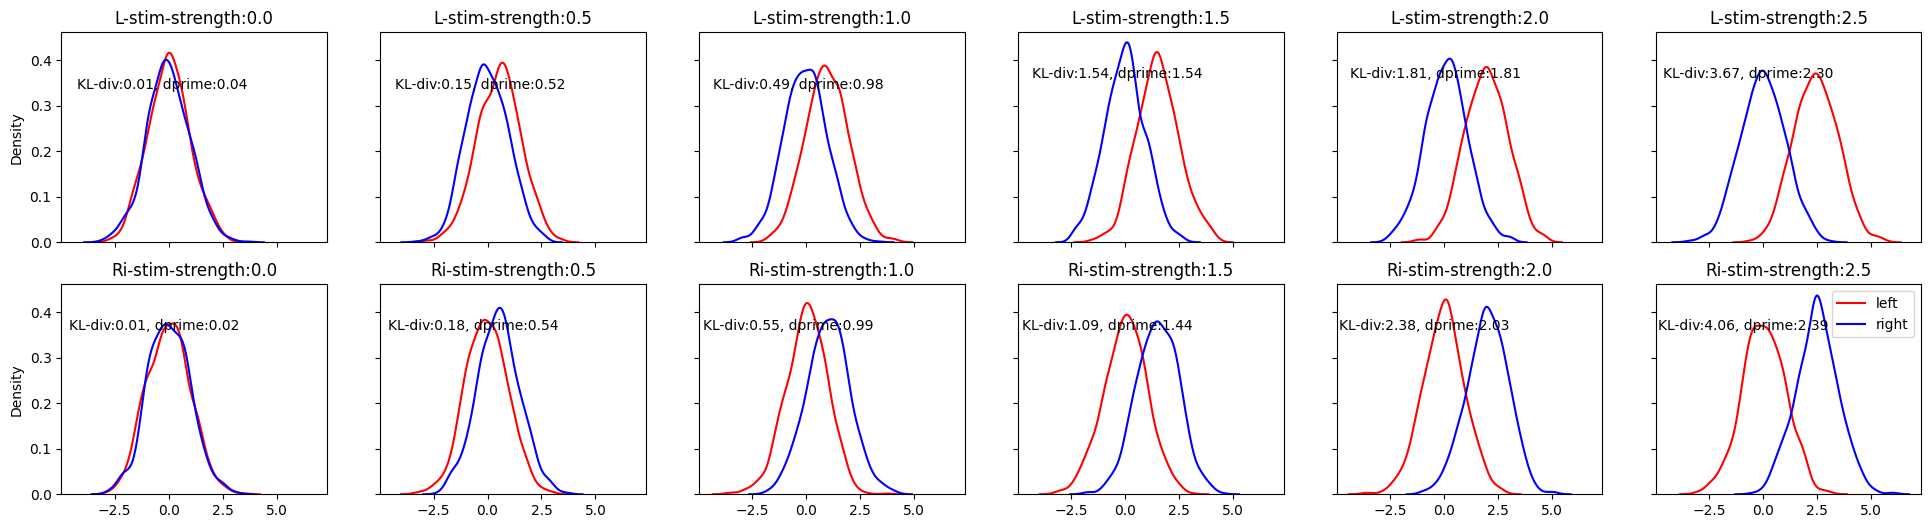

In [12]:
# original data transformation
# OG data

stimulus_generator()  # with no parameters, it is the original data

### Choice D Analysis <br>


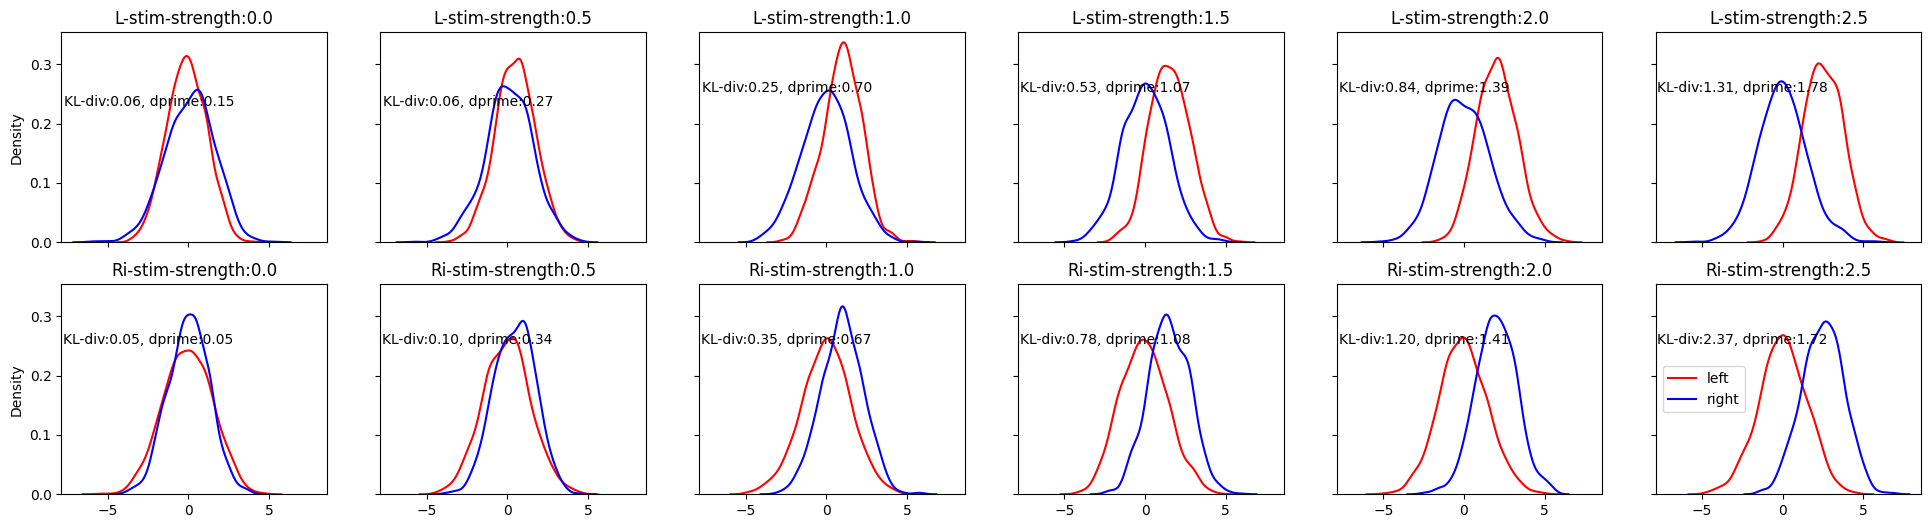

In [13]:
stimulus_generator(signal_scale=1.25, noise_scale=1.5)

In [14]:
# noise scale is 1.5, signal scale is 1.25

In [282]:
files = glob("../../ann-rnn-modified/data/noisydatachoiced/*.pkl")

# proper regex sort
numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))
# load all but the first one
# we can rewrite this into a function later

with open(sorted_files[1], "rb") as f:
    data = pkl.load(f)
session_data_init = data["session_data"]
with open(sorted_files[-1], "rb") as f:
    data = pkl.load(f)
session_data_final = data["session_data"]

'../../ann-rnn-modified/data/noisydatachoiced/rnn_ann_model_results_10units_5000.pkl'

In [3]:
# run all the stuff
# MI, TE, PID etc

# organize session info


def epochs(session_data):
    t_end = session_data.loc[
        session_data["action_taken"] == 1,
        [
            "block_side",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
        ],
    ]
    t_end["signed_trial_strength"] /= t_end["signed_trial_strength"].max()

    t_0 = session_data.loc[
        session_data["trial_start"] == 1,
        [
            "block_side",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "concordant_trial",
        ],
    ]

    iloc = np.where((session_data["action_taken"] == 1) == True)[0]
    t_penultimate = session_data.iloc[iloc - 1][
        [
            "block_side",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "concordant_trial",
        ]
    ]
    t_penultimate["action_side"] = t_end["action_side"].values

    t_penultimate_non_zero = t_penultimate.loc[
        (t_penultimate["right_stimulus"] != 0) | (t_penultimate["left_stimulus"] != 0)
    ]

    # now for t_end for zero contrast trials, split by correct and incorrect choices
    t_zero_contrast = t_end[t_end["signed_trial_strength"] == 0]

    # find correct and incorrect indices

    hidden_state_t_0 = np.concatenate(t_0["hidden_state"].values)
    hidden_state_t_penultimate = np.concatenate(t_penultimate["hidden_state"].values)
    hidden_state_t_penultimate_non_zero = np.concatenate(
        t_penultimate_non_zero["hidden_state"].values
    )
    hidden_state_t_end = np.concatenate(t_end["hidden_state"].values)
    hidden_state_t_zero_contrast = np.concatenate(t_zero_contrast["hidden_state"].values)

    return (
        t_0,
        t_penultimate,
        t_end,
        t_penultimate_non_zero,
        t_zero_contrast,
        hidden_state_t_0,
        hidden_state_t_penultimate,
        hidden_state_t_penultimate_non_zero,
        hidden_state_t_end,
        hidden_state_t_zero_contrast,
    )

In [283]:
(
    t_0_init,
    t_penultimate_init,
    t_end_init,
    t_penultimate_non_zero_init,
    t_zero_contrast_init,
    hidden_state_t_0_init,
    hidden_state_t_penultimate_init,
    hidden_state_t_penultimate_non_zero_init,
    hidden_state_t_end_init,
    hidden_state_t_zero_contrast_init,
) = epochs(session_data_init)

(
    t_0_final,
    t_penultimate_final,
    t_end_final,
    t_penultimate_non_zero_final,
    t_zero_contrast_final,
    hidden_state_t_0_final,
    hidden_state_t_penultimate_final,
    hidden_state_t_penultimate_non_zero_final,
    hidden_state_t_end_final,
    hidden_state_t_zero_contrast_final,
) = epochs(session_data_final)

In [293]:
init_decisions = t_end_init.correct_action_taken.values
final_decisions = t_end_final.correct_action_taken.values

527

In [315]:
t_end_init[(t_end_init["correct_action_taken"] == 1) & (t_end_init["signed_trial_strength"] == 0)][
    "rnn_step_index"
].count()

t_end_init[(t_end_init["correct_action_taken"] == 0) & (t_end_init["signed_trial_strength"] == 0)][
    "rnn_step_index"
].count()

317

In [316]:
t_end_final[
    (t_end_final["correct_action_taken"] == 1) & (t_end_final["signed_trial_strength"] == 0)
]["rnn_step_index"].count()

498

In [317]:
t_end_final[
    (t_end_final["correct_action_taken"] == 0) & (t_end_final["signed_trial_strength"] == 0)
]["rnn_step_index"].count()

328

Text(0.5, 0, 'Training Iteration')

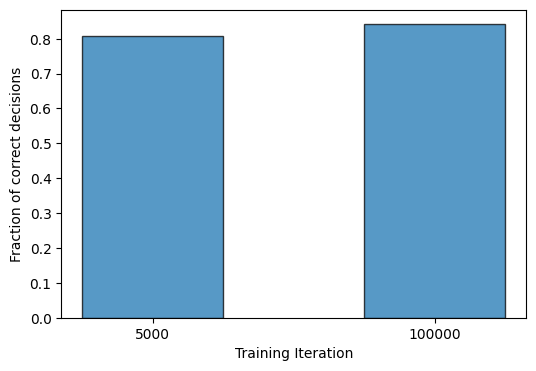

In [302]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    np.arange(2),
    [
        np.sum(init_decisions) / init_decisions.shape[0],
        np.sum(final_decisions) / final_decisions.shape[0],
    ],
    width=0.5,
    edgecolor="k",
    alpha=0.75,
)
ax.set_xticks(np.arange(2), labels=["5000", "100000"])
ax.set_ylabel("Fraction of correct decisions")
ax.set_xlabel("Training Iteration")

In [17]:
def find_optimal_discretization_kfold(X, Y, max_bins=20, n_folds=5, random_state=42):
    """
    Find optimal discretization for multiple features using cross-validation.

    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized.
    Y : array-like of shape (n_timepoints,)
        Target variable.
    max_bins : int, default=20
        Maximum number of bins to consider.
    n_folds : int, default=5
        Number of folds for cross-validation.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature.
        - 'mi_train_scores': List of mutual information scores for each feature on training folds.
        - 'mi_test_scores': List of mutual information scores for each feature on validation folds.
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()

    # Ensure X is 2D
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Split the data using KFold
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    mi_train_scores = []
    mi_test_scores = []
    optimal_bin_list = []

    for train_idx, val_idx in tqdm(kf.split(X), desc="Cross-validation folds"):
        X_train, X_val = X[train_idx, :], X[val_idx, :]
        y_train, y_val = Y[train_idx], Y[val_idx]

        # Store MI scores for each bin count
        feature_mi_train = []
        feature_mi_test = []
        optimal_bins_per_feature = []

        for feature_idx in range(X.shape[1]):
            # Extract a single feature
            X_train_feature = X_train[:, feature_idx]
            X_val_feature = X_val[:, feature_idx]

            # Optimize bins for this feature
            mi_scores_train = []
            for n_bins in range(2, max_bins + 1):
                # Discretize with current bin count
                discretizer = KBinsDiscretizer(
                    n_bins=n_bins, encode="ordinal", strategy="quantile"
                )
                X_train_discretized = discretizer.fit_transform(
                    X_train_feature.reshape(-1, 1)
                ).ravel()

                # Compute MI on training set
                mi_scores_train.append(MI(X_train_discretized, y_train))

            # Find the optimal bin count for the feature
            optimal_bins = np.argmax(mi_scores_train) + 2  # +2 because bins start from 2
            optimal_bins_per_feature.append(optimal_bins)

            # Evaluate on validation set
            discretizer = KBinsDiscretizer(
                n_bins=optimal_bins, encode="ordinal", strategy="quantile"
            )
            X_val_discretized = discretizer.fit_transform(X_val_feature.reshape(-1, 1)).ravel()
            mi_test = MI(X_val_discretized, y_val)

            # Store MI scores
            feature_mi_train.append(mi_scores_train)
            feature_mi_test.append(mi_test)

        # Append results for this fold
        mi_train_scores.append(feature_mi_train)
        mi_test_scores.append(feature_mi_test)
        optimal_bin_list.append(optimal_bins_per_feature)

    # Format results
    results = {
        "optimal_bins": np.array(optimal_bin_list),
        "mi_train_scores": np.array(mi_train_scores),
        "mi_test_scores": np.array(mi_test_scores),
    }

    return results

In [254]:
# now we find these reults for all epochs, all the different variables of interest

# block side, grouped by left and right side, look at stimulus info at each point, look at action side information

In [255]:
results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# now for t penultimate
results_trial_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["trial_side"].values
)
results_block_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["block_side"].values
)
results_left_stimulus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["left_stimulus"].values
)
results_right_stimlus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["right_stimulus"].values
)
results_action_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["action_side"].values
)

# now for t end
results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)


# now for t zero contrast
results_trial_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["trial_side"].values
)
results_block_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["block_side"].values
)
results_action_side_end_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["action_side"].values
)

Cross-validation folds: 5it [00:02,  2.08it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.18it/s]
Cross-validation folds: 5it [00:02,  2.11it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.14it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.09it/s]
Cross-validation folds: 5it [00:02,  2.14it/s]
Cross-validation folds: 5it [00:02,  2.13it/s]
Cross-validation folds: 5it [00:00,  8.92it/s]
Cross-validation folds: 5it [00:00,  9.06it/s]
Cross-validation folds: 5it [00:00,  9.21it/s]


Text(0.5, 0.98, 'MI for T0')

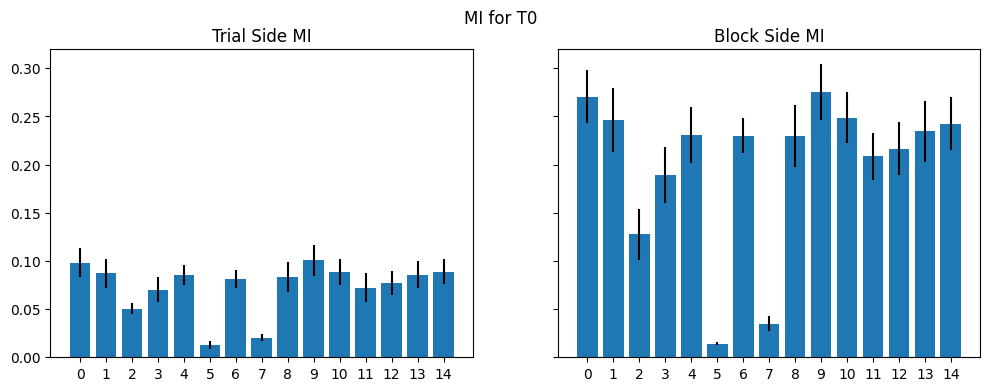

In [256]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True, sharex=True)
ax[0].bar(
    np.arange(15),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(15),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(15))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
plt.suptitle("MI for T0")

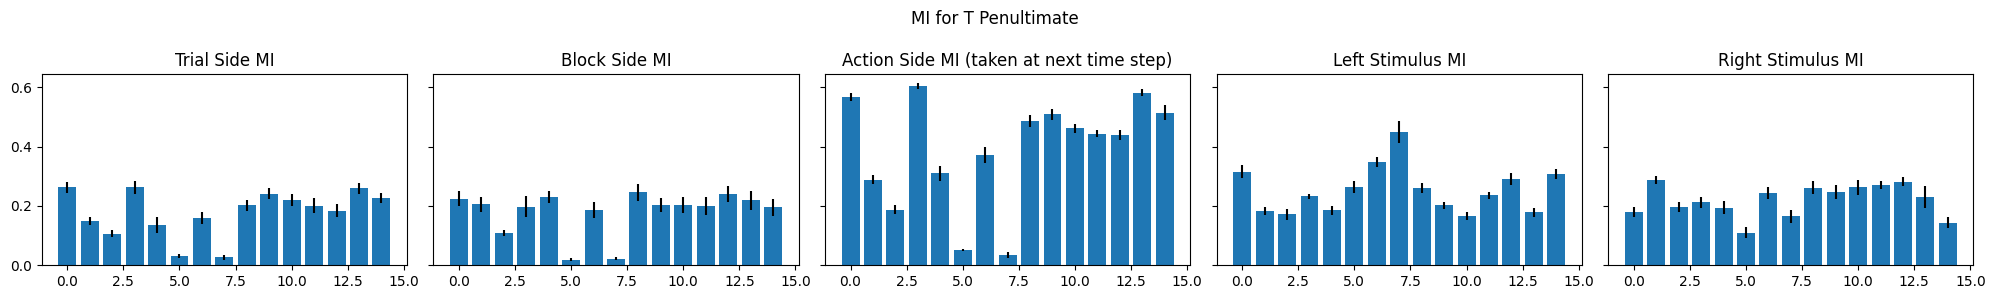

In [257]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_action_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_penultimate["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_penultimate["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T Penultimate")
plt.tight_layout()

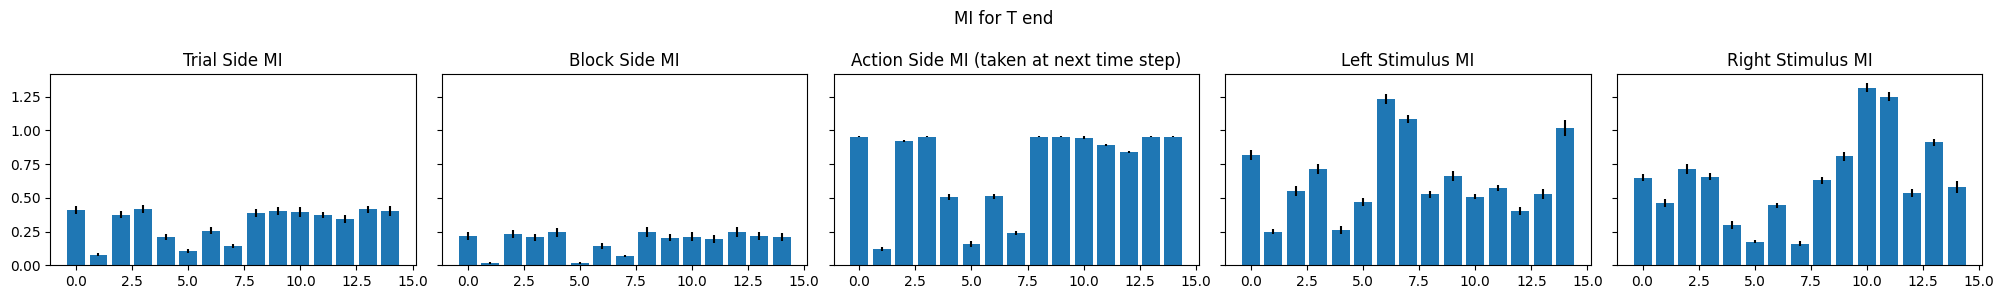

In [258]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T end")
plt.tight_layout()

In [259]:
def organize_data(
    results_trial_side,
    results_block_side,
    results_trial_side_penultimate,
    results_block_side_penultimate,
    results_left_stimulus_penultimate,
    results_right_stimlus_penultimate,
    results_action_side_penultimate,
    results_trial_side_end,
    results_block_side_end,
    results_left_stimulus_end,
    results_right_stimlus_end,
    results_action_side_end,
    idx,
):

    trial_scores_mean = [
        results_trial_side["mi_test_scores"][:, idx].mean(axis=0),
        results_trial_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    trial_scores_std = [
        results_trial_side["mi_test_scores"][:, idx].std(axis=0),
        results_trial_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    block_scores_mean = [
        results_block_side["mi_test_scores"][:, idx].mean(axis=0),
        results_block_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    block_scores_std = [
        results_block_side["mi_test_scores"][:, idx].std(axis=0),
        results_block_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    action_scores_mean = [
        results_action_side_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_action_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    action_scores_std = [
        results_action_side_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_action_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    left_stimulus_scores_mean = [
        results_left_stimulus_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_left_stimulus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    left_stimulus_scores_std = [
        results_left_stimulus_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_left_stimulus_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    right_stimulus_scores_mean = [
        results_right_stimlus_penultimate["mi_test_scores"][:, idx].mean(axis=0),
        results_right_stimlus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    right_stimulus_scores_std = [
        results_right_stimlus_penultimate["mi_test_scores"][:, idx].std(axis=0),
        results_right_stimlus_end["mi_test_scores"][:, idx].std(axis=0),
    ]
    return (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    )

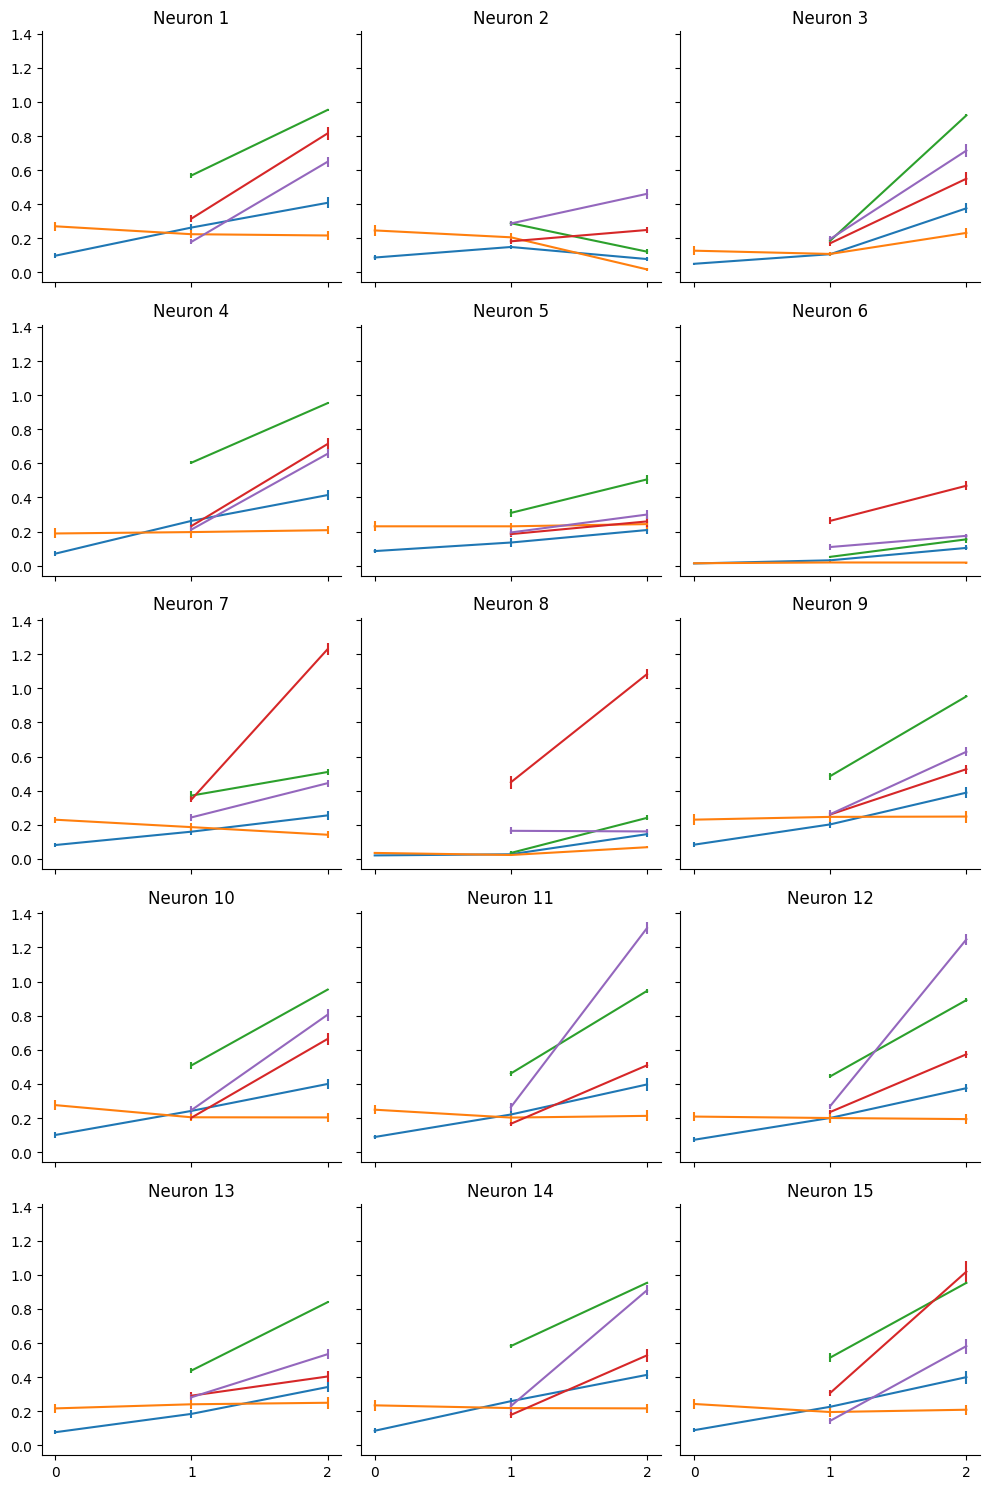

In [260]:
# plot the change in MI for each condition and each epoch
# essentially collapse the bar charts into line graphs, with one line for each hidden neuron

# plot each neuron in a separate subplot, and group the time series together

fig, ax = plt.subplots(figsize=(10, 15), ncols=3, nrows=5, sharey=True, sharex=True)

for idx, axes in enumerate(ax.flatten()):

    # have to reorganize
    (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    ) = organize_data(
        results_trial_side,
        results_block_side,
        results_trial_side_penultimate,
        results_block_side_penultimate,
        results_left_stimulus_penultimate,
        results_right_stimlus_penultimate,
        results_action_side_penultimate,
        results_trial_side_end,
        results_block_side_end,
        results_left_stimulus_end,
        results_right_stimlus_end,
        results_action_side_end,
        idx,
    )

    # now to plot, maybe clean everything up in a function now

    zero_indexed = np.arange(0, 3)
    one_indexed = np.arange(1, 3)

    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)

    axes.errorbar(zero_indexed, trial_scores_mean, yerr=trial_scores_std, label="Trial Side")
    axes.errorbar(zero_indexed, block_scores_mean, yerr=block_scores_std, label="Block Side")
    axes.errorbar(one_indexed, action_scores_mean, yerr=action_scores_std, label="Action Side")
    axes.errorbar(
        one_indexed,
        left_stimulus_scores_mean,
        yerr=left_stimulus_scores_std,
        label="Left Stimulus",
    )
    axes.errorbar(
        one_indexed,
        right_stimulus_scores_mean,
        yerr=right_stimulus_scores_std,
        label="Right Stimulus",
    )
    axes.set_title(f"Neuron {idx+1}")
    axes.set_xticks(zero_indexed)
    plt.tight_layout()

In [261]:
# this is not so nice, make heatmaps instead
trial_scores_hp = np.zeros((15, 3))
block_scores_hp = np.zeros((15, 3))
action_scores_hp = np.zeros((15, 2))
left_scores_hp = np.zeros((15, 2))
right_scores_hp = np.zeros((15, 2))

for idx in range(15):

    # have to reorganize
    (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    ) = organize_data(
        results_trial_side,
        results_block_side,
        results_trial_side_penultimate,
        results_block_side_penultimate,
        results_left_stimulus_penultimate,
        results_right_stimlus_penultimate,
        results_action_side_penultimate,
        results_trial_side_end,
        results_block_side_end,
        results_left_stimulus_end,
        results_right_stimlus_end,
        results_action_side_end,
        idx,
    )

    trial_scores_hp[idx, :] = trial_scores_mean
    block_scores_hp[idx, :] = block_scores_mean
    action_scores_hp[idx, :] = action_scores_mean
    left_scores_hp[idx, :] = left_stimulus_scores_mean
    right_scores_hp[idx, :] = right_stimulus_scores_mean

[Text(0.5, 0, '1'), Text(1.5, 0, '2')]

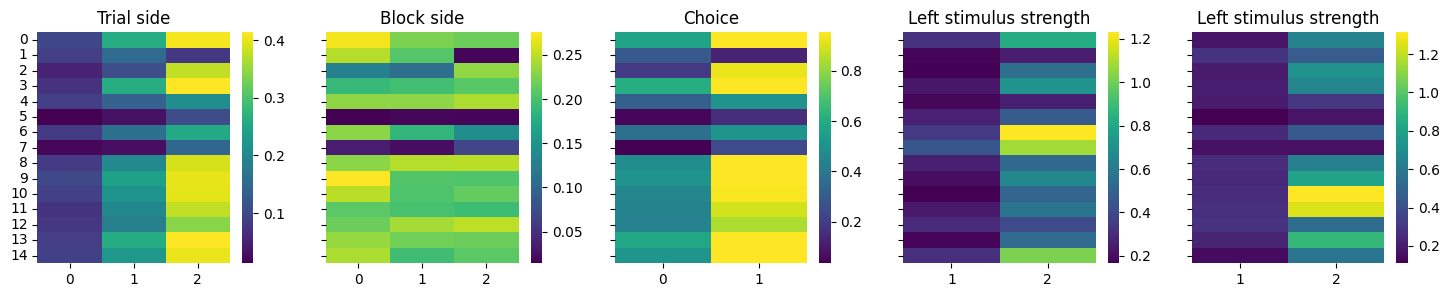

In [262]:
fig, ax = plt.subplots(figsize=(18, 3), ncols=5, sharey=True)

sns.heatmap(trial_scores_hp, ax=ax[0], cmap="viridis")
ax[0].set_title("Trial side")
sns.heatmap(block_scores_hp, ax=ax[1], cmap="viridis")
ax[1].set_title("Block side")
sns.heatmap(action_scores_hp, ax=ax[2], cmap="viridis")
ax[2].set_title("Choice")
sns.heatmap(left_scores_hp, ax=ax[3], cmap="viridis")
ax[3].set_title("Left stimulus strength")
ax[3].set_xticklabels([1, 2])
sns.heatmap(right_scores_hp, ax=ax[4], cmap="viridis")
ax[4].set_title("Left stimulus strength")
ax[4].set_xticklabels([1, 2])

In [278]:
np.sum(session_data.correct_action_taken == 1) / np.max(session_data["trial_within_session"])

0.8088968681428287

<Axes: >

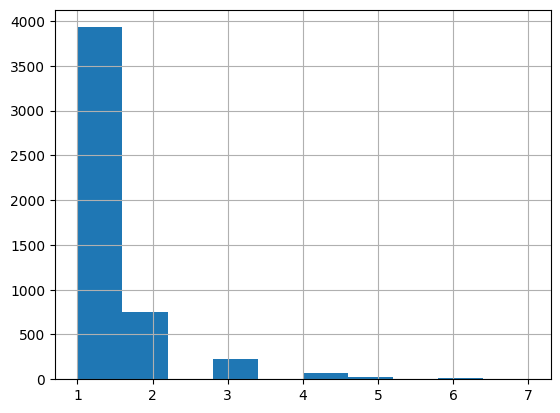

In [281]:
t_end.rnn_step_index.hist()

### Choice E

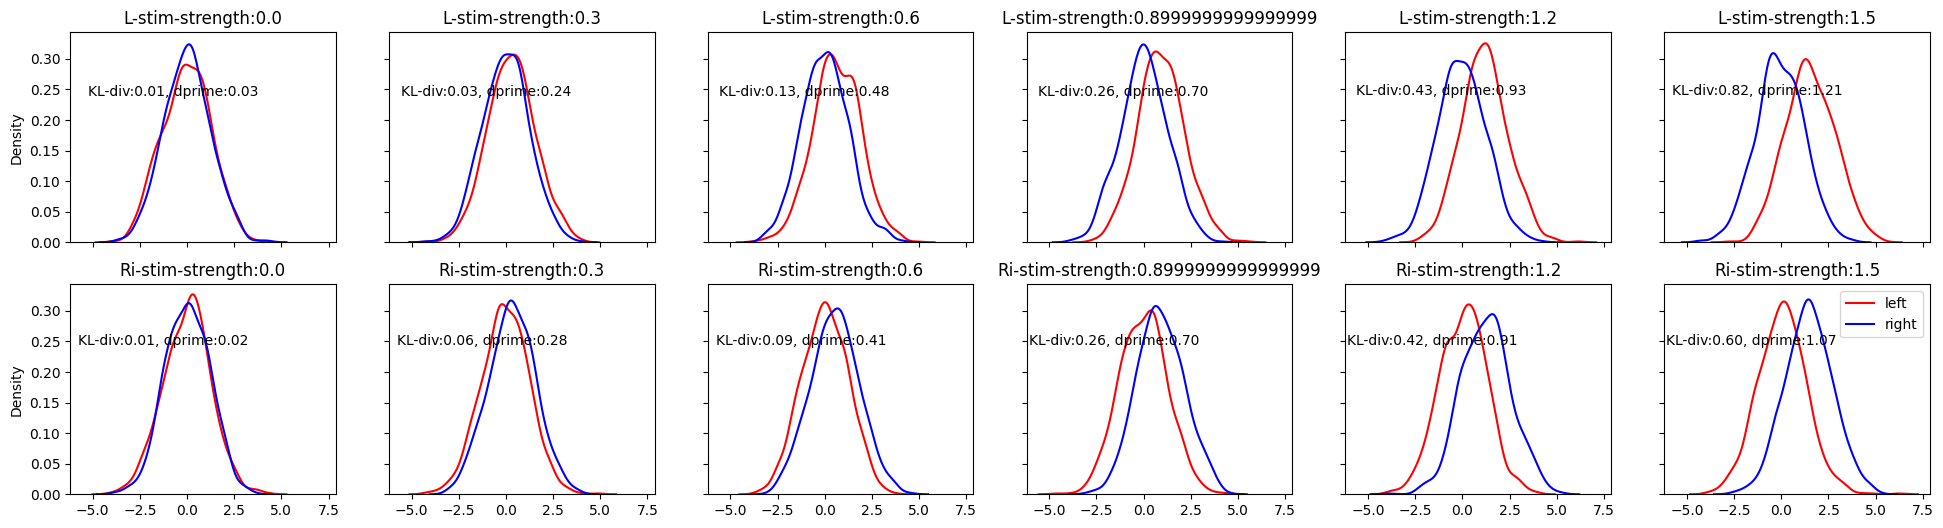

In [230]:
stimulus_generator(
    possible_trial_strengths=tuple(np.linspace(0, 1.5, 6)), signal_scale=1.25, noise_scale=1.25
)

In [332]:
files = glob("../../ann-rnn-modified/data/noisydatachoicee/*.pkl")

# proper regex sort
numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))
# load all but the first one
# we can rewrite this into a function later

with open(sorted_files[-1], "rb") as f:
    data = pkl.load(f)
session_data = data["session_data"]

In [333]:
(
    t_0,
    t_penultimate,
    t_end,
    t_penultimate_non_zero,
    t_zero_contrast,
    hidden_state_t_0,
    hidden_state_t_penultimate,
    hidden_state_t_penultimate_non_zero,
    hidden_state_t_end,
    hidden_state_t_zero_contrast,
) = epochs(session_data)

In [334]:
results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# now for t penultimate
results_trial_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["trial_side"].values
)
results_block_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["block_side"].values
)
results_left_stimulus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["left_stimulus"].values
)
results_right_stimlus_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["right_stimulus"].values
)
results_action_side_penultimate = find_optimal_discretization_kfold(
    hidden_state_t_penultimate, t_penultimate["action_side"].values
)

# now for t end
results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)


# now for t zero contrast
results_trial_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["trial_side"].values
)
results_block_side_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["block_side"].values
)
results_action_side_end_zero_contrast = find_optimal_discretization_kfold(
    hidden_state_t_zero_contrast, t_zero_contrast["action_side"].values
)

Cross-validation folds: 5it [00:02,  2.08it/s]
Cross-validation folds: 5it [00:02,  2.11it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.15it/s]
Cross-validation folds: 5it [00:02,  2.24it/s]
Cross-validation folds: 5it [00:02,  2.23it/s]
Cross-validation folds: 5it [00:02,  2.19it/s]
Cross-validation folds: 5it [00:02,  2.21it/s]
Cross-validation folds: 5it [00:02,  2.19it/s]
Cross-validation folds: 5it [00:02,  2.17it/s]
Cross-validation folds: 5it [00:02,  2.16it/s]
Cross-validation folds: 5it [00:02,  2.18it/s]
Cross-validation folds: 5it [00:00,  9.21it/s]
Cross-validation folds: 5it [00:00,  9.17it/s]
Cross-validation folds: 5it [00:00,  9.26it/s]


Text(0.5, 0.98, 'MI for T0')

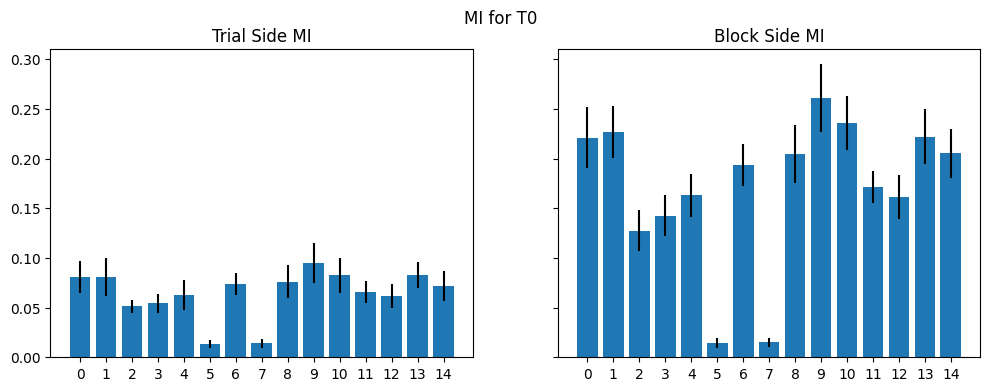

In [335]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True, sharex=True)
ax[0].bar(
    np.arange(15),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(15),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(15))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
plt.suptitle("MI for T0")

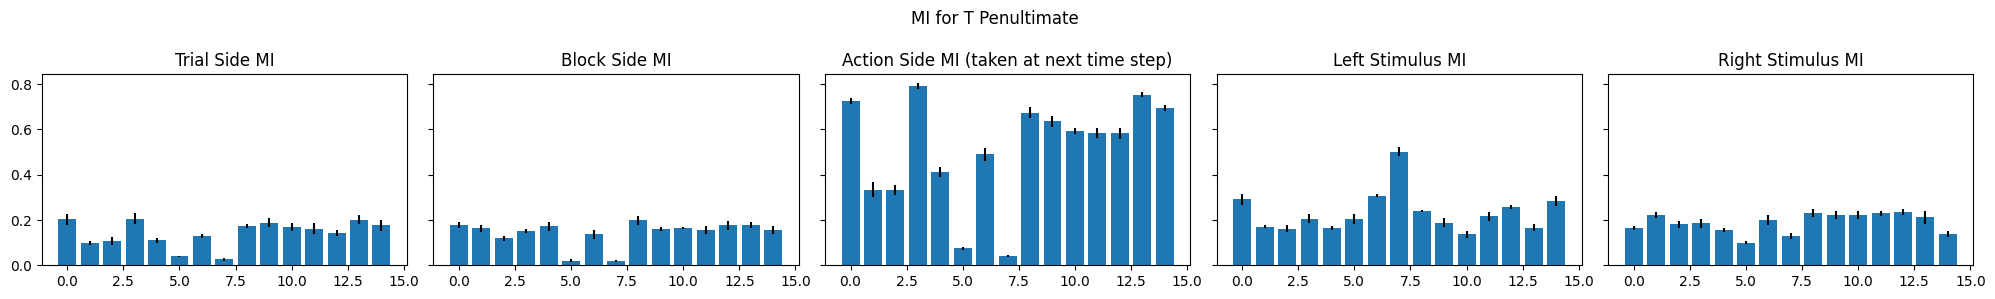

In [336]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_action_side_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_penultimate["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_penultimate["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_penultimate["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_penultimate["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T Penultimate")
plt.tight_layout()

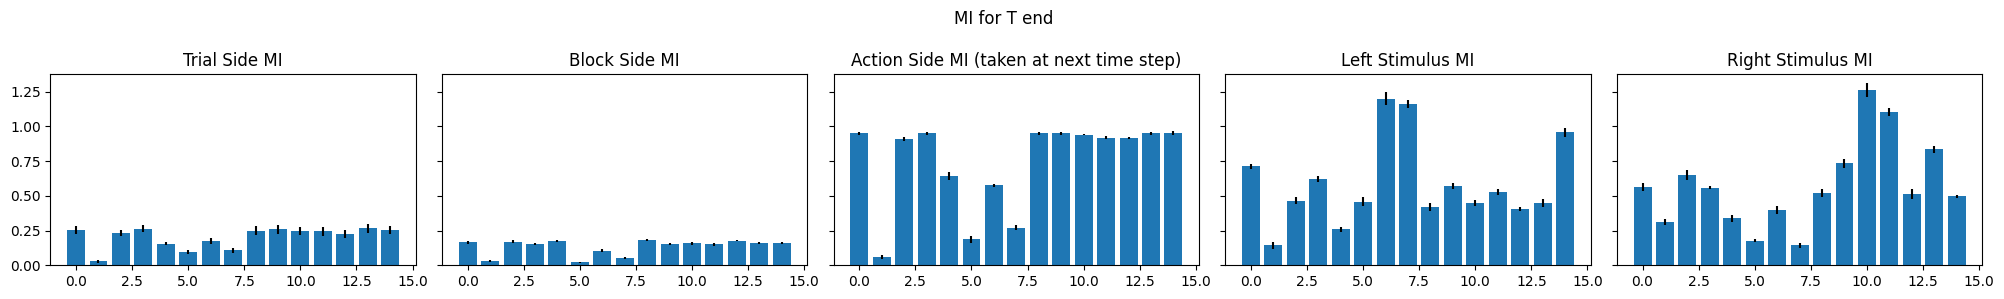

In [337]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(15),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(15),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(15),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(15),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(15),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T end")
plt.tight_layout()

In [338]:
# this is not so nice, make heatmaps instead
trial_scores_hp = np.zeros((15, 3))
block_scores_hp = np.zeros((15, 3))
action_scores_hp = np.zeros((15, 2))
left_scores_hp = np.zeros((15, 2))
right_scores_hp = np.zeros((15, 2))

for idx in range(15):

    # have to reorganize
    (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    ) = organize_data(
        results_trial_side,
        results_block_side,
        results_trial_side_penultimate,
        results_block_side_penultimate,
        results_left_stimulus_penultimate,
        results_right_stimlus_penultimate,
        results_action_side_penultimate,
        results_trial_side_end,
        results_block_side_end,
        results_left_stimulus_end,
        results_right_stimlus_end,
        results_action_side_end,
        idx,
    )

    trial_scores_hp[idx, :] = trial_scores_mean
    block_scores_hp[idx, :] = block_scores_mean
    action_scores_hp[idx, :] = action_scores_mean
    left_scores_hp[idx, :] = left_stimulus_scores_mean
    right_scores_hp[idx, :] = right_stimulus_scores_mean

[Text(0.5, 0, '1'), Text(1.5, 0, '2')]

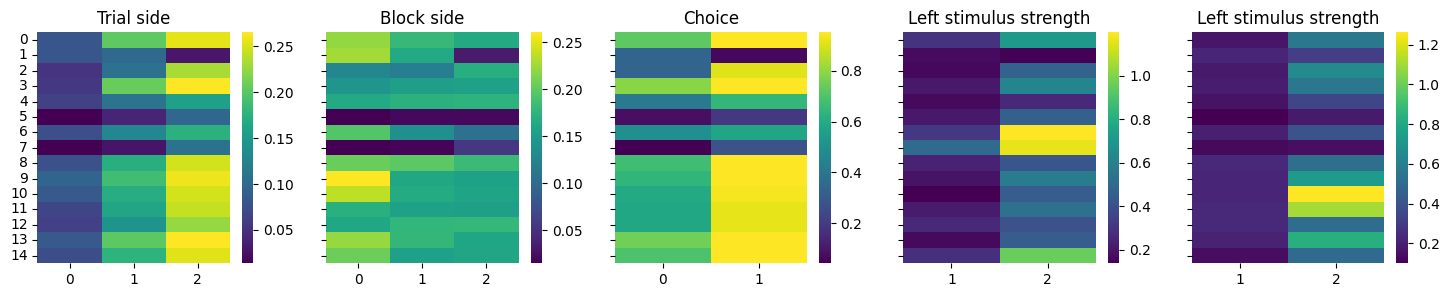

In [339]:
fig, ax = plt.subplots(figsize=(18, 3), ncols=5, sharey=True)

sns.heatmap(trial_scores_hp, ax=ax[0], cmap="viridis")
ax[0].set_title("Trial side")
sns.heatmap(block_scores_hp, ax=ax[1], cmap="viridis")
ax[1].set_title("Block side")
sns.heatmap(action_scores_hp, ax=ax[2], cmap="viridis")
ax[2].set_title("Choice")
sns.heatmap(left_scores_hp, ax=ax[3], cmap="viridis")
ax[3].set_title("Left stimulus strength")
ax[3].set_xticklabels([1, 2])
sns.heatmap(right_scores_hp, ax=ax[4], cmap="viridis")
ax[4].set_title("Left stimulus strength")
ax[4].set_xticklabels([1, 2])

<Axes: >

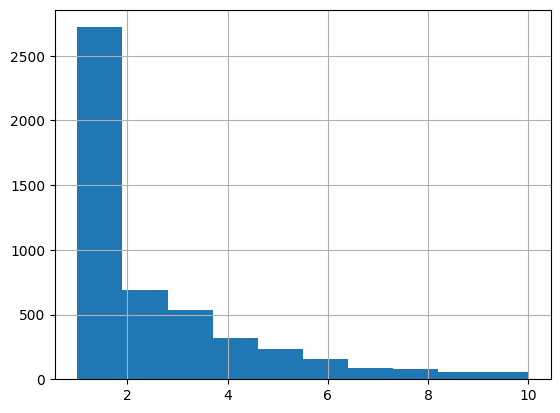

In [340]:
t_end.rnn_step_index.hist()

<Axes: >

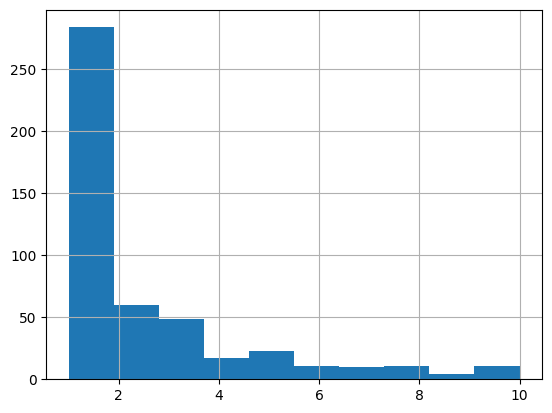

In [341]:
t_end[(t_end["correct_action_taken"] == 1) & (t_end["signed_trial_strength"] == 0)][
    "rnn_step_index"
].hist()

<Axes: >

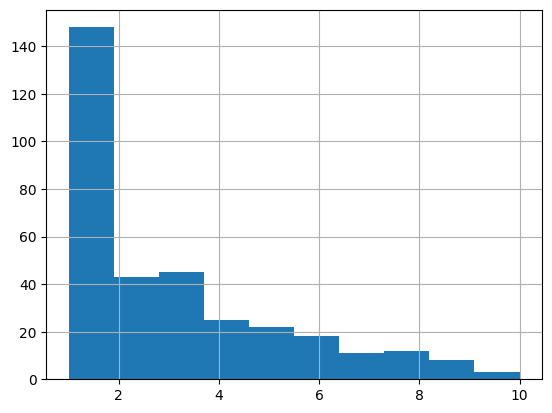

In [342]:
t_end[(t_end["correct_action_taken"] == 0) & (t_end["signed_trial_strength"] == 0)][
    "rnn_step_index"
].hist()

In [331]:
session_data.correct_action_taken.sum() / session_data.correct_action_taken.count()

0.7333466294375748

In [343]:
session_data.correct_action_taken.sum() / session_data.correct_action_taken.count()

0.7638611886717191

Text(0.5, 0, 'Training Iteration')

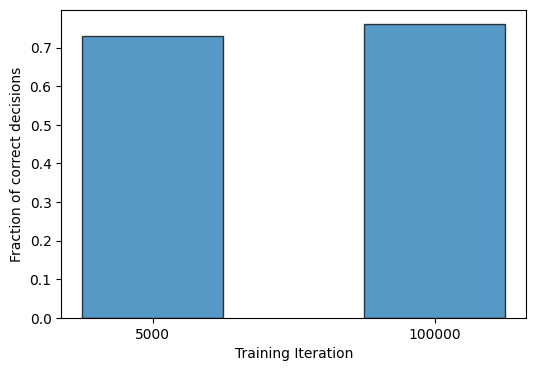

In [344]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    np.arange(2),
    [0.73, 0.76],
    width=0.5,
    edgecolor="k",
    alpha=0.75,
)
ax.set_xticks(np.arange(2), labels=["5000", "100000"])
ax.set_ylabel("Fraction of correct decisions")
ax.set_xlabel("Training Iteration")

In [ ]:
epochs

### Simple Experiment 
    - 1 stimulus strength, no bias

In [7]:
files = glob("../../ann-rnn-modified/data/twoneurons/*.pkl")

# proper regex sort
numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))
# load all but the first one
# we can rewrite this into a function later

print(sorted_files)

['../../ann-rnn-modified/data/twoneurons/_1000.pkl', '../../ann-rnn-modified/data/twoneurons/_5000.pkl', '../../ann-rnn-modified/data/twoneurons/_10000.pkl']


In [12]:
# we use checkpoint at 10000 iterations
with open(sorted_files[1], "rb") as f:
    data = pkl.load(f)
session_data = data["session_data"]

In [13]:
session_data.correct_action_taken.sum() / session_data.correct_action_taken.count()

0.993019545273235

In [14]:
def shorter_epoches(session_data):
    t_end = session_data.loc[
        session_data["action_taken"] == 1,
        [
            "block_side",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
        ],
    ]
    t_end["signed_trial_strength"] /= t_end["signed_trial_strength"].max()

    t_0 = session_data.loc[
        session_data["trial_start"] == 1,
        [
            "block_side",
            "signed_trial_strength",
            "action_side",
            "trial_side",
            "correct_action_taken",
            "hidden_state",
            "left_stimulus",
            "right_stimulus",
            "rnn_step_index",
            "concordant_trial",
        ],
    ]
    # find correct and incorrect indices
    t_incorrect = t_end[t_end["correct_action_taken"] != 1]
    hidden_state_t_incorrect = np.concatenate(t_incorrect["hidden_state"].values)

    hidden_state_t_0 = np.concatenate(t_0["hidden_state"].values)
    hidden_state_t_end = np.concatenate(t_end["hidden_state"].values)

    return t_0, t_end, t_incorrect, hidden_state_t_0, hidden_state_t_end, hidden_state_t_incorrect

In [15]:
t_0, t_end, t_incorrect, hidden_state_t_0, hidden_state_t_end, hidden_state_t_incorrect = (
    shorter_epoches(session_data)
)

In [18]:
results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# now for t end
results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)

Cross-validation folds: 5it [00:00, 15.44it/s]
Cross-validation folds: 5it [00:00, 16.21it/s]
Cross-validation folds: 5it [00:00, 16.25it/s]
Cross-validation folds: 5it [00:00, 16.35it/s]
Cross-validation folds: 5it [00:00, 16.27it/s]
Cross-validation folds: 5it [00:00, 16.16it/s]
Cross-validation folds: 5it [00:00, 16.05it/s]


In [22]:
# such a simple task, no incorrectness

# results_trial_side_incorrect = find_optimal_discretization_kfold(
#     hidden_state_t_incorrect, t_incorrect["trial_side"].values
# )
# results_block_side_incorrect = find_optimal_discretization_kfold(
#     hidden_state_t_incorrect, t_incorrect["block_side"].values
# )
# results_left_stimulus_incorrect = find_optimal_discretization_kfold(
#     hidden_state_t_incorrect, t_incorrect["left_stimulus"].values
# )
# results_right_stimlus_incorrect = find_optimal_discretization_kfold(
#     hidden_state_t_incorrect, t_incorrect["right_stimulus"].values
# )
# results_action_side_incorrect = find_optimal_discretization_kfold(
#     hidden_state_t_incorrect, t_incorrect["action_side"].values
# )

In [25]:
n_neurons = hidden_state_t_0.shape[-1]

Text(0.5, 0.98, 'MI for T0')

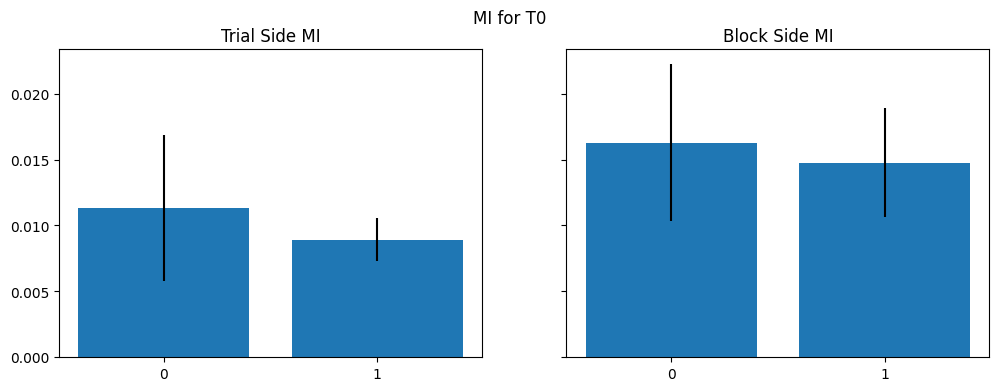

In [26]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True, sharex=True)
ax[0].bar(
    np.arange(n_neurons),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(n_neurons),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(n_neurons))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
plt.suptitle("MI for T0")

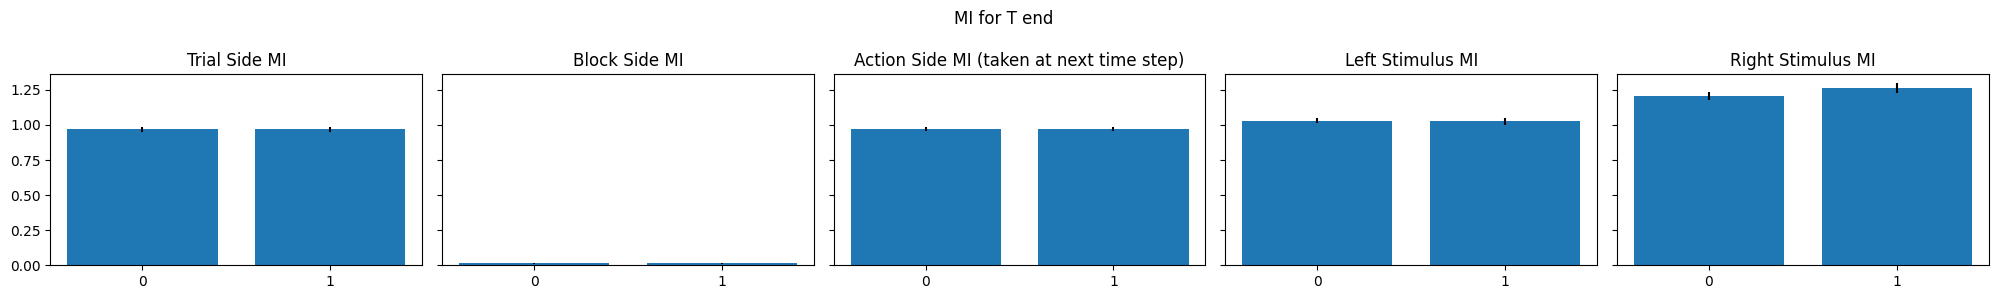

In [28]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(n_neurons),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(n_neurons),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(n_neurons),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(n_neurons),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(n_neurons),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")
ax[1].set_xticks(np.arange(n_neurons))
plt.suptitle("MI for T end")
plt.tight_layout()

In [29]:
# fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

# ax[0].bar(
#     np.arange(4),
#     results_trial_side_incorrect["mi_test_scores"].mean(axis=0),
#     yerr=results_trial_side_incorrect["mi_test_scores"].std(axis=0),
# )
# ax[0].set_title("Trial Side MI")
# ax[1].bar(
#     np.arange(4),
#     results_block_side_incorrect["mi_test_scores"].mean(axis=0),
#     yerr=results_block_side_incorrect["mi_test_scores"].std(axis=0),
# )
# ax[1].set_title("Block Side MI")

# ax[2].bar(
#     np.arange(4),
#     results_action_side_incorrect["mi_test_scores"].mean(axis=0),
#     yerr=results_action_side_incorrect["mi_test_scores"].std(axis=0),
# )
# ax[2].set_title("Action Side MI (taken at next time step)")

# ax[3].bar(
#     np.arange(4),
#     results_left_stimulus_incorrect["mi_test_scores"].mean(axis=0),
#     yerr=results_left_stimulus_incorrect["mi_test_scores"].std(axis=0),
# )
# ax[3].set_title("Left Stimulus MI")

# ax[4].bar(
#     np.arange(4),
#     results_right_stimlus_incorrect["mi_test_scores"].mean(axis=0),
#     yerr=results_right_stimlus_incorrect["mi_test_scores"].std(axis=0),
# )
# ax[4].set_title("Right Stimulus MI")

# plt.suptitle("MI for T incorrect")
# plt.tight_layout()

In [30]:
def organize_lesser_data(
    results_trial_side,
    results_block_side,
    results_trial_side_end,
    results_block_side_end,
    results_left_stimulus_end,
    results_right_stimlus_end,
    results_action_side_end,
    idx,
):

    trial_scores_mean = [
        results_trial_side["mi_test_scores"][:, idx].mean(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    trial_scores_std = [
        results_trial_side["mi_test_scores"][:, idx].std(axis=0),
        results_trial_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    block_scores_mean = [
        results_block_side["mi_test_scores"][:, idx].mean(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    block_scores_std = [
        results_block_side["mi_test_scores"][:, idx].std(axis=0),
        results_block_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    action_scores_mean = [
        results_action_side_end["mi_test_scores"][:, idx].mean(axis=0),
    ]
    action_scores_std = [
        results_action_side_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    left_stimulus_scores_mean = [
        results_left_stimulus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    left_stimulus_scores_std = [
        results_left_stimulus_end["mi_test_scores"][:, idx].std(axis=0),
    ]

    right_stimulus_scores_mean = [
        results_right_stimlus_end["mi_test_scores"][:, idx].mean(axis=0),
    ]

    right_stimulus_scores_std = [
        results_right_stimlus_end["mi_test_scores"][:, idx].std(axis=0),
    ]
    return (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    )

In [32]:
trial_scores_hp = np.zeros((n_neurons, 2))
block_scores_hp = np.zeros((n_neurons, 2))
action_scores_hp = np.zeros((n_neurons, 1))
left_scores_hp = np.zeros((n_neurons, 1))
right_scores_hp = np.zeros((n_neurons, 1))

for idx in range(n_neurons):

    # have to reorganize
    (
        trial_scores_mean,
        trial_scores_std,
        block_scores_mean,
        block_scores_std,
        action_scores_mean,
        action_scores_std,
        left_stimulus_scores_mean,
        left_stimulus_scores_std,
        right_stimulus_scores_mean,
        right_stimulus_scores_std,
    ) = organize_lesser_data(
        results_trial_side,
        results_block_side,
        results_trial_side_end,
        results_block_side_end,
        results_left_stimulus_end,
        results_right_stimlus_end,
        results_action_side_end,
        idx,
    )

    trial_scores_hp[idx, :] = trial_scores_mean
    block_scores_hp[idx, :] = block_scores_mean
    action_scores_hp[idx, :] = action_scores_mean
    left_scores_hp[idx, :] = left_stimulus_scores_mean
    right_scores_hp[idx, :] = right_stimulus_scores_mean

[Text(0.5, 0, '1')]

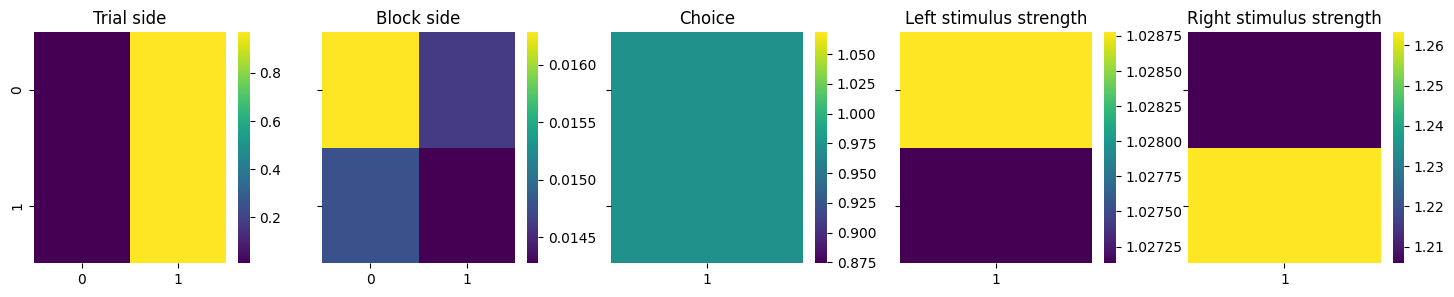

In [35]:
fig, ax = plt.subplots(figsize=(18, 3), ncols=5, sharey=True)

sns.heatmap(trial_scores_hp, ax=ax[0], cmap="viridis")
ax[0].set_title("Trial side")
sns.heatmap(block_scores_hp, ax=ax[1], cmap="viridis")
ax[1].set_title("Block side")
sns.heatmap(action_scores_hp, ax=ax[2], cmap="viridis")
ax[2].set_title("Choice")
ax[2].set_xticklabels([1])
sns.heatmap(left_scores_hp, ax=ax[3], cmap="viridis")
ax[3].set_title("Left stimulus strength")
ax[3].set_xticklabels([1])
sns.heatmap(right_scores_hp, ax=ax[4], cmap="viridis")
ax[4].set_title("Right stimulus strength")
ax[4].set_xticklabels([1])

In [36]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids = []
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])

    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids


def discretize_hidden_state(hidden_state, n_bins=15):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille.
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """

    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        # bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        # bin_edges = np.percentile(row, [25,50,75])
        # discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(
            row, q=n_bins, labels=False, duplicates="drop", retbins=True
        )
        discrete_data[idx, :] = discrete_row

    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data


def compute_information_decomposition(decoding_variable, neural_data):
    # always same region
    # neural data is in neurons x trials
    targets = decoding_variable
    sources = generate_source_ids(neural_data.shape[0])

    pid_information = np.zeros((len(sources), 4))  # neuronsC2 x 4
    coinformation_data = np.zeros((len(sources), 4))  # neuronsC2 x 4

    for idx in tqdm(range(len(sources)), desc="Running for all sources", leave=False):
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid_unbiased(Y, X1, X2)
        coinfo, mi_yx1x2, mi_yx1, mi_yx2 = coinformation(Y, X1, X2)
        pid_information[idx, :] = u1, u2, red, syn
        coinformation_data[idx, :] = mi_yx1, mi_yx2, coinfo, mi_yx1x2

    # now to organize this?
    # nah, unique information would just be the mean of the first two
    # red and syn  are fine
    # yx1 and yx2 mutual info are also similar to UI
    # the other two are trivariate

    return pid_information, coinformation_data

In [37]:
def get_all_pid(t_0, t_end, hidden_state_t_0, hidden_state_t_end):

    # discretize
    discretized_hidden_state_t_0 = discretize_hidden_state(hidden_state_t_0.T)
    discretized_hidden_state_t_end = discretize_hidden_state(hidden_state_t_end.T)

    # compute all mutual informations

    # for t0 and t-1, no action

    pid_information, coinformation_data = compute_information_decomposition(
        t_0["trial_side"].values, discretized_hidden_state_t_0
    )
    trial_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_0["block_side"].values, discretized_hidden_state_t_0
    )
    block_side_t0 = np.hstack([pid_information, coinformation_data])

    # for tend, compute all

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["trial_side"].values, discretized_hidden_state_t_end
    )
    trial_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["block_side"].values, discretized_hidden_state_t_end
    )
    block_side_tend = np.hstack([pid_information, coinformation_data])

    # action

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["action_side"].values, discretized_hidden_state_t_0
    )
    action_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(
        t_end["action_side"].values, discretized_hidden_state_t_end
    )
    action_side_tend = np.hstack([pid_information, coinformation_data])

    # compute bayes and hidden state for all

    # compute means for different catagories, and then plot them
    # we could do this stacking, but maybe after computing the means

    trial_side_t0_mean = np.mean(trial_side_t0, axis=0)
    block_side_t0_mean = np.mean(block_side_t0, axis=0)
    trial_side_tend_mean = np.mean(trial_side_tend, axis=0)
    block_side_tend_mean = np.mean(block_side_tend, axis=0)
    action_side_t0_mean = np.mean(action_side_t0, axis=0)

    action_side_tend_mean = np.mean(action_side_tend, axis=0)

    trial_side_t0_std = np.std(trial_side_t0, axis=0)
    block_side_t0_std = np.std(block_side_t0, axis=0)
    trial_side_tend_std = np.std(trial_side_tend, axis=0)
    block_side_tend_std = np.std(block_side_tend, axis=0)
    action_side_t0_std = np.std(action_side_t0, axis=0)

    action_side_tend_std = np.std(action_side_tend, axis=0)

    # maybe it makes more sense to plot the activity of each unit rather than the

    Block_side_mean_stack = np.stack([block_side_t0_mean, block_side_tend_mean], axis=1)
    Stim_side_mean_stack = np.stack([trial_side_t0_mean, trial_side_tend_mean], axis=1)
    Action_side_mean_stack = np.stack([action_side_t0_mean, action_side_tend_mean], axis=1)

    Block_side_std_stack = np.stack([block_side_t0_std, block_side_tend_std], axis=1)
    Stim_side_std_stack = np.stack([trial_side_t0_std, trial_side_tend_std], axis=1)
    Action_side_std_stack = np.stack([action_side_t0_std, action_side_tend_std], axis=1)

    fig, ax = plt.subplots(figsize=(15, 3), ncols=3, sharey=True, sharex=True)

    ax[0].bar(
        np.arange(2) - 0.25,
        Block_side_mean_stack[2, :],
        width=0.25,
        yerr=Block_side_std_stack[2, :] / 2,
    )
    ax[0].bar(
        np.arange(2), Block_side_mean_stack[3, :], width=0.25, yerr=Block_side_std_stack[3, :] / 2
    )
    ax[0].bar(
        np.arange(2) + 0.25,
        Block_side_mean_stack[-1, :],
        width=0.25,
        yerr=Block_side_std_stack[-1, :] / 2,
    )
    ax[0].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[0].set_xlabel("RNN time step")
    ax[0].set_title("Block Side Representation")

    ax[1].bar(
        np.arange(2) - 0.25,
        Stim_side_mean_stack[2, :],
        width=0.25,
        yerr=Stim_side_std_stack[2, :] / 2,
    )
    ax[1].bar(
        np.arange(2), Stim_side_mean_stack[3, :], width=0.25, yerr=Stim_side_std_stack[3, :] / 2
    )
    ax[1].bar(
        np.arange(2) + 0.25,
        Stim_side_mean_stack[-1, :],
        width=0.25,
        yerr=Stim_side_std_stack[-1, :] / 2,
    )
    ax[1].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[1].set_xlabel("RNN time step")
    ax[1].set_title("Stim Side Representation")

    ax[2].bar(
        np.arange(2) - 0.25,
        Action_side_mean_stack[2, :],
        width=0.25,
        yerr=Action_side_std_stack[2, :] / 2,
        label="Redundancy",
    )
    ax[2].bar(
        np.arange(2),
        Action_side_mean_stack[3, :],
        width=0.25,
        yerr=Action_side_std_stack[3, :] / 2,
        label="Synergy",
    )
    ax[2].bar(
        np.arange(2) + 0.25,
        Action_side_mean_stack[-1, :],
        width=0.25,
        yerr=Action_side_std_stack[-1, :] / 2,
        label="total MI",
    )
    ax[2].set_xticks(np.arange(2), labels=["t0", "t_action"])
    ax[2].set_xlabel("RNN time step")
    ax[2].set_title("Choice Side Representation")

    plt.legend()

    return (
        Block_side_mean_stack,
        Stim_side_mean_stack,
        Action_side_mean_stack,
        Block_side_std_stack,
        Stim_side_std_stack,
        Action_side_std_stack,
    )

100%|██████████| 2/2 [00:00<00:00, 1005.47it/s]


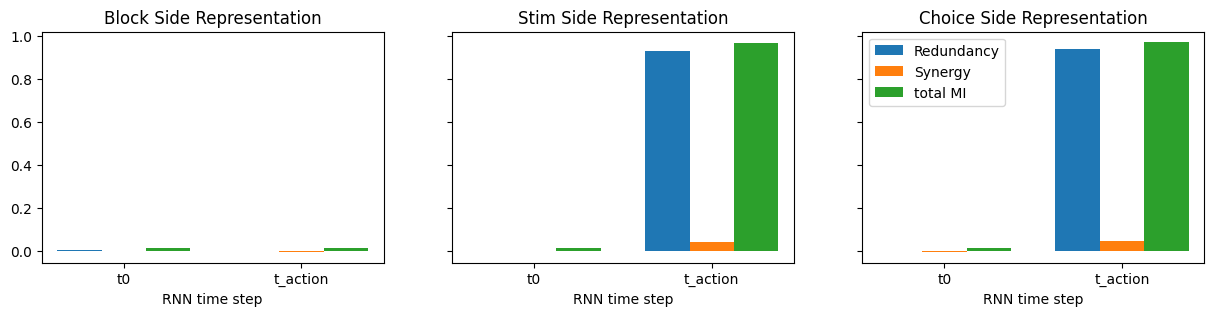

In [38]:
(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
) = get_all_pid(t_0, t_end, hidden_state_t_0, hidden_state_t_end)

<Axes: >

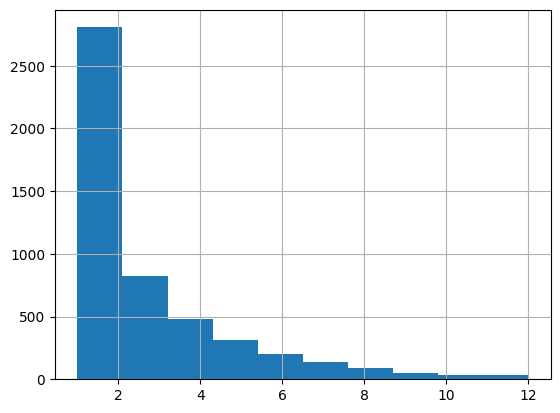

In [39]:
t_end.rnn_step_index.hist()

### Two stimulus sets
- still easy task

In [61]:
files = glob("../../ann-rnn-modified/data/doubleStimulusRun/*.pkl")

# proper regex sort
numbered_files = [f for f in files if re.search(r"\d+.pkl$", f)]
sorted_files = sorted(numbered_files, key=lambda x: int(re.search(r"(\d+).pkl$", x).group(1)))
# load all but the first one
# we can rewrite this into a function later

with open(sorted_files[-1], "rb") as f:
    data = pkl.load(f)
session_data = data["session_data"]

In [62]:
t_0, t_end, t_incorrect, hidden_state_t_0, hidden_state_t_end, hidden_state_t_incorrect = (
    shorter_epoches(session_data)
)

results_trial_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["trial_side"].values)
results_block_side = find_optimal_discretization_kfold(hidden_state_t_0, t_0["block_side"].values)


# now for t end
results_trial_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["trial_side"].values
)
results_block_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["block_side"].values
)
results_left_stimulus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["left_stimulus"].values
)
results_right_stimlus_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["right_stimulus"].values
)
results_action_side_end = find_optimal_discretization_kfold(
    hidden_state_t_end, t_end["action_side"].values
)


results_trial_side_incorrect = find_optimal_discretization_kfold(
    hidden_state_t_incorrect, t_incorrect["trial_side"].values
)
results_block_side_incorrect = find_optimal_discretization_kfold(
    hidden_state_t_incorrect, t_incorrect["block_side"].values
)
results_left_stimulus_incorrect = find_optimal_discretization_kfold(
    hidden_state_t_incorrect, t_incorrect["left_stimulus"].values
)
results_right_stimlus_incorrect = find_optimal_discretization_kfold(
    hidden_state_t_incorrect, t_incorrect["right_stimulus"].values
)
results_action_side_incorrect = find_optimal_discretization_kfold(
    hidden_state_t_incorrect, t_incorrect["action_side"].values
)

Cross-validation folds: 5it [00:01,  3.08it/s]
Cross-validation folds: 5it [00:01,  3.26it/s]
Cross-validation folds: 5it [00:01,  3.30it/s]
Cross-validation folds: 5it [00:01,  3.29it/s]
Cross-validation folds: 5it [00:01,  3.36it/s]
Cross-validation folds: 5it [00:01,  3.32it/s]
Cross-validation folds: 5it [00:01,  3.32it/s]
Cross-validation folds: 5it [00:00, 18.23it/s]
Cross-validation folds: 5it [00:00, 17.83it/s]
Cross-validation folds: 5it [00:00, 17.80it/s]
Cross-validation folds: 5it [00:00, 17.22it/s]
Cross-validation folds: 5it [00:00, 17.36it/s]


Text(0.5, 0.98, 'MI for T0')

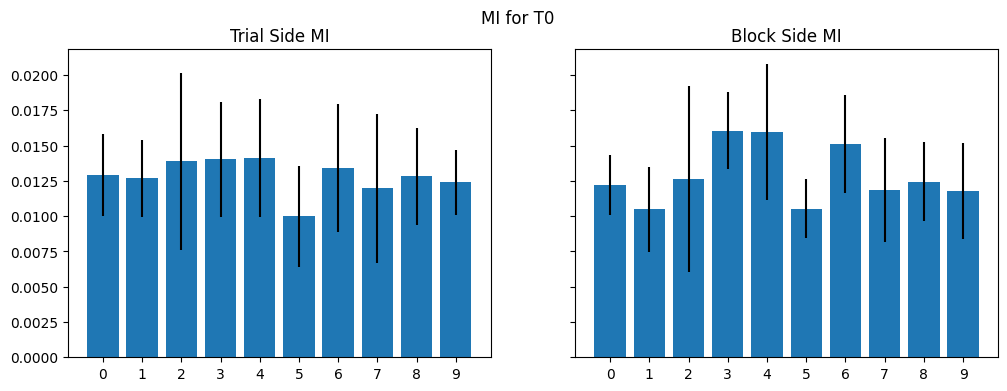

In [64]:
fig, ax = plt.subplots(figsize=(12, 4), ncols=2, sharey=True, sharex=True)
ax[0].bar(
    np.arange(10),
    results_trial_side["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side["mi_test_scores"].std(axis=0),
)
ax[1].bar(
    np.arange(10),
    results_block_side["mi_test_scores"].mean(axis=0),
    yerr=results_block_side["mi_test_scores"].std(axis=0),
)
ax[1].set_xticks(np.arange(10))
ax[0].set_title("Trial Side MI")
ax[1].set_title("Block Side MI")
plt.suptitle("MI for T0")

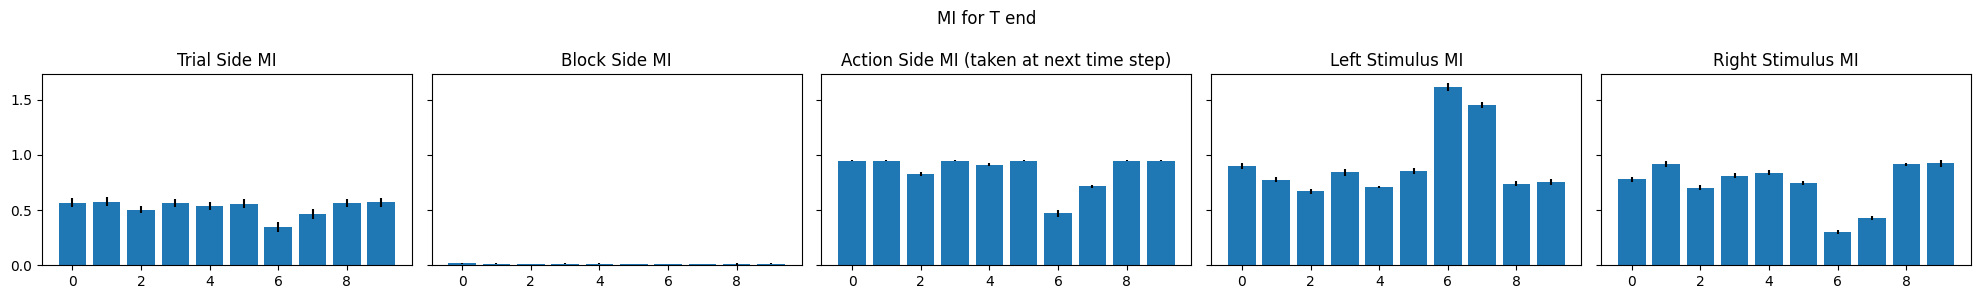

In [65]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_end["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_end["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_action_side_end["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_end["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(10),
    results_left_stimulus_end["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_end["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(10),
    results_right_stimlus_end["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_end["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T end")
plt.tight_layout()

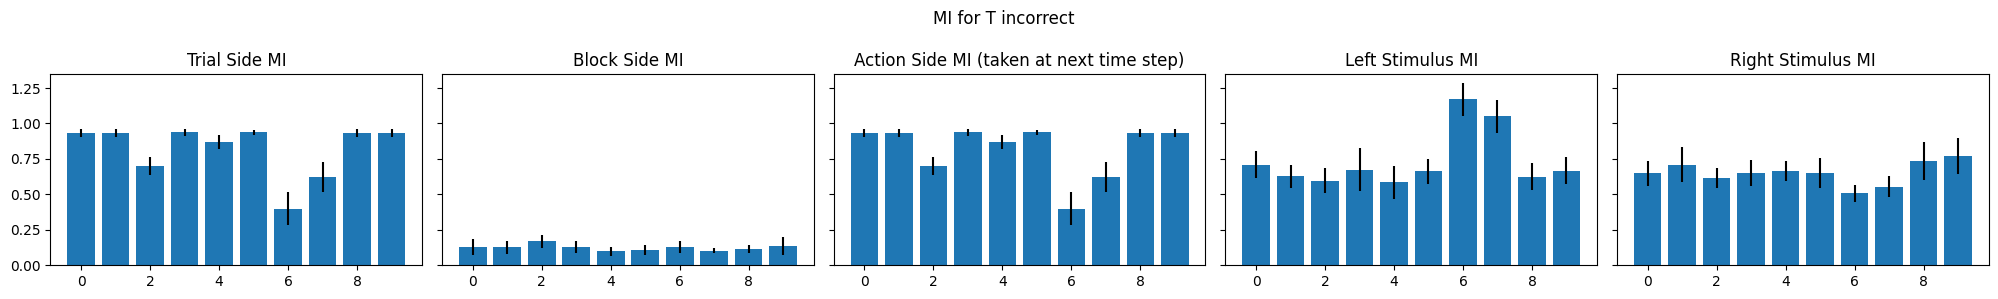

In [67]:
fig, ax = plt.subplots(figsize=(20, 3), ncols=5, sharey=True, sharex=True)

ax[0].bar(
    np.arange(10),
    results_trial_side_incorrect["mi_test_scores"].mean(axis=0),
    yerr=results_trial_side_incorrect["mi_test_scores"].std(axis=0),
)
ax[0].set_title("Trial Side MI")
ax[1].bar(
    np.arange(10),
    results_block_side_incorrect["mi_test_scores"].mean(axis=0),
    yerr=results_block_side_incorrect["mi_test_scores"].std(axis=0),
)
ax[1].set_title("Block Side MI")

ax[2].bar(
    np.arange(10),
    results_action_side_incorrect["mi_test_scores"].mean(axis=0),
    yerr=results_action_side_incorrect["mi_test_scores"].std(axis=0),
)
ax[2].set_title("Action Side MI (taken at next time step)")

ax[3].bar(
    np.arange(10),
    results_left_stimulus_incorrect["mi_test_scores"].mean(axis=0),
    yerr=results_left_stimulus_incorrect["mi_test_scores"].std(axis=0),
)
ax[3].set_title("Left Stimulus MI")

ax[4].bar(
    np.arange(10),
    results_right_stimlus_incorrect["mi_test_scores"].mean(axis=0),
    yerr=results_right_stimlus_incorrect["mi_test_scores"].std(axis=0),
)
ax[4].set_title("Right Stimulus MI")

plt.suptitle("MI for T incorrect")
plt.tight_layout()

100%|██████████| 10/10 [00:00<00:00, 799.69it/s]


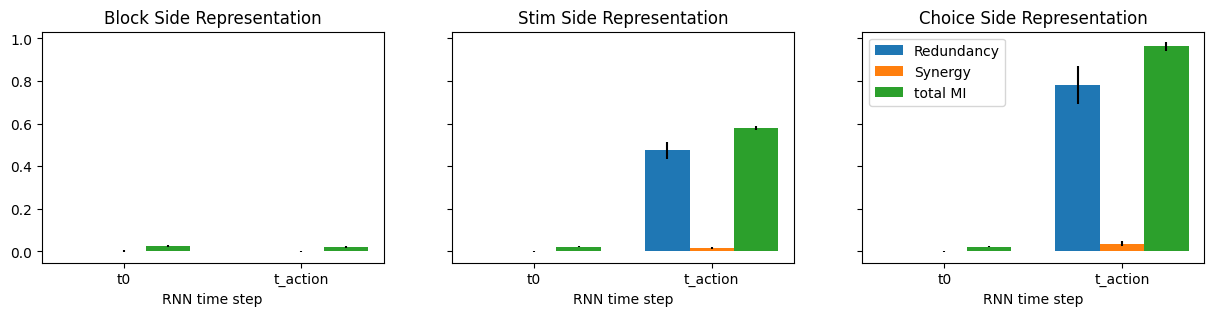

In [68]:
(
    Block_side_mean_stack,
    Stim_side_mean_stack,
    Action_side_mean_stack,
    Block_side_std_stack,
    Stim_side_std_stack,
    Action_side_std_stack,
) = get_all_pid(t_0, t_end, hidden_state_t_0, hidden_state_t_end)